In this project we're going to **replicating a machine learning paper** and creating a Vision Transfomer from scratch using PyTorch .

We'll then see how ViT, a state-of-the-art computer vision architecture, performs on our FoodVision Mini problem.

Goal of **Paper replicating** is to replicate the advances with code so that one can use the techniques for his own problem

For example, let's say a new model architecture gets released that performs better than any other architecture before on various benchmarks, wouldn't it be nice to try that architecture on your own problems?

##Why replicate a machine learning research paper?

A machine learning research paper is often a presentation of months of work and experiments done by some of the best machine learning teams in the world condensed into a few pages of text.

And if these experiments lead to better results in an area related to the problem you're working on, it'd be nice to check them out.

Also, replicating the work of others is a fantastic way to practice your skills.


ViT : Stands for Vision Transformer

##Getting setup


In [4]:
# For this notebook to run with updated APIs , we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1] >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+")
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")



[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://download.pytorch.org/whl/cu118
torch version: 2.8.0+cu126
torchvision version: 0.23.0+cu126


In [5]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 37.56 MiB/s, done.
Resolving deltas: 100% (2656/2656), done.
Updating files: 100% (248/248), done.


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

##Get Data

In [7]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [8]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path /"test"

##2.Create DataSets and DataLoaders

##2.1 Prepare transforms for Images

In [9]:
# Ceate images size (from Table 3 in the ViT paper )
IMG_SIZE = 224

# Create a transform pipeline manually
manual_transforms  = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


##Turn Images to DataLoader's

In [10]:
BATCH_SIZE = 32  # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7903f0ee3dd0>,
 ['pizza', 'steak', 'sushi'])

##2.3 Visualise a single image
To do so, let's get a single image and label from a batch of data and inspect their shapes.

In [11]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

#  Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(torch.Size([3, 224, 224]), tensor(2))

plotting the image and its label with `matplotlib`



(torch.Size([3, 224, 224]), tensor(2))

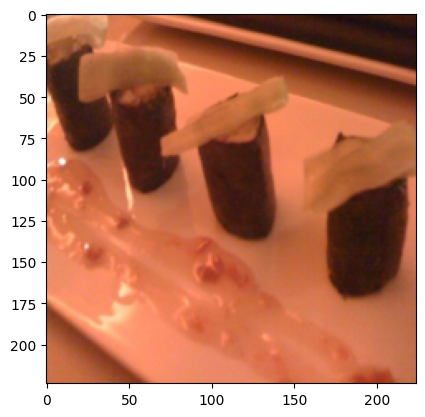

In [12]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0))   # rearrange iamge dimensions to suit the matplotlib [color_channels, height, width] -> [height, width, color_channels]

# Get a single image from the batch
image, label  = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

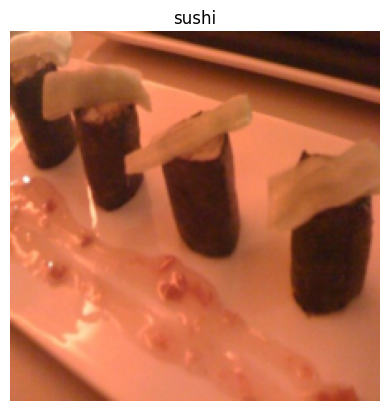

In [13]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

##3.1 Inputs and outputs, layer and blocks
ViT is a deep learning neural network architecture.


And any neural network architecture is generally comprised of **layers**.

And a collection of layers is often referred to as a **block**.

And stacking many blocks together is what gives us the whole architecture.

A **layer** takes an input (say an image tensor), performs some kind of function on it (for example what's in the layer's forward() method) and then returns an output.

So if a **single layer** takes an input and gives an output, then a collection of layers or a **block** also takes an input and gives an output.



##4.1 Calculating patch embedding input and output shapes by hand

How about we start by calculating these input and output shape values by hand?

To do so, let's create some variables to mimic each of the terms (such as H,W etc) above.

We'll use a patch size (P) of 16 since it's the best performing version of ViT-Base uses (see column "ViT-B/16" of Table 5 in the ViT paper for more).

In [14]:
# Create eg: values
height = 224 # H ( The training resolution is 224)
width = 224 # W
color_channels = 3 # C
patch_size = 16 # P

# Calculate N (number of patches)
number_of_patches = int(height * width / patch_size**2)
print(f"Number_of_patches (N) with image height (H={height}), width (W={width}), and patch size (P={patch_size}): {number_of_patches}")


Number_of_patches (N) with image height (H=224), width (W=224), and patch size (P=16): 196


We've got the number of patches, how about we create the image output size as well?

Better yet, let's replicate the input and output shapes of the patch embedding layer.

Recall:

    Input: The image starts as 2D with size H X W X C

  
    Output: The image gets converted to a sequence of flattened 2D patches with size N x (P**2 x C)
.

In [15]:
# Input shape (this is the size of a single image)
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D Image) : {embedding_layer_input_shape}")
print(f"Output shape (Single 2D Image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D Image) : (224, 224, 3)
Output shape (Single 2D Image flattened into patches): (196, 768)


##Turning a single image into patches

Now we know the ideal input and output shapes for our patch embedding layer, let's move towards making it.

What we're doing is breaking down the overall architecture into smaller pieces, focusing on the inputs and outputs of individual layers.


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

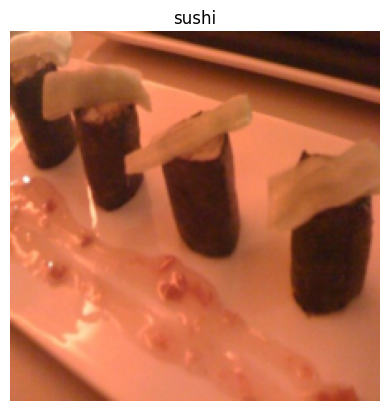

In [16]:
# View a single image
plt.imshow(image.permute(1, 2, 0))  # Adjust for matplotlib
plt.title(class_names[label])
plt.axis(False)


We want to turn this image into patches of itself inline with Figure 1 of the ViT paper.

How about we start by just visualizing the top row of patched pixels?
We can do this by indexing on the different image dimensions.

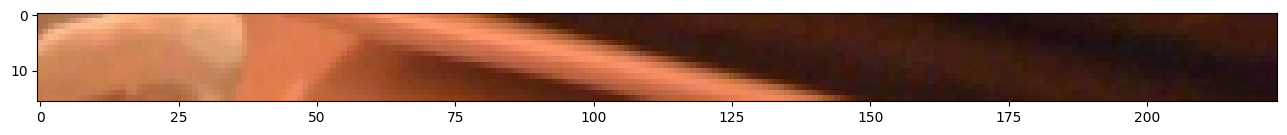

In [17]:
# Change the image shape to be compatible with matplotlib (color_channels,height, width) -> (height, wdth, color)
image_permuted = image.permute(1, 2, 0)

# Index to plot the top row of patched pixels
patch_size = 16
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :]);


Now that we got the top row, let's turn it into patches

We can do this by iterating through the number of patches there'd be in the top row


Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


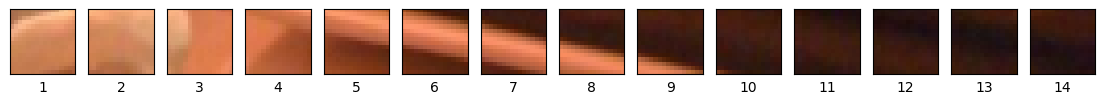

In [18]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size, # one column for each patch
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Iterate through number of patches in the top row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :]); # keep height index constant, alter the width index
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Doing the patches to whole the image

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


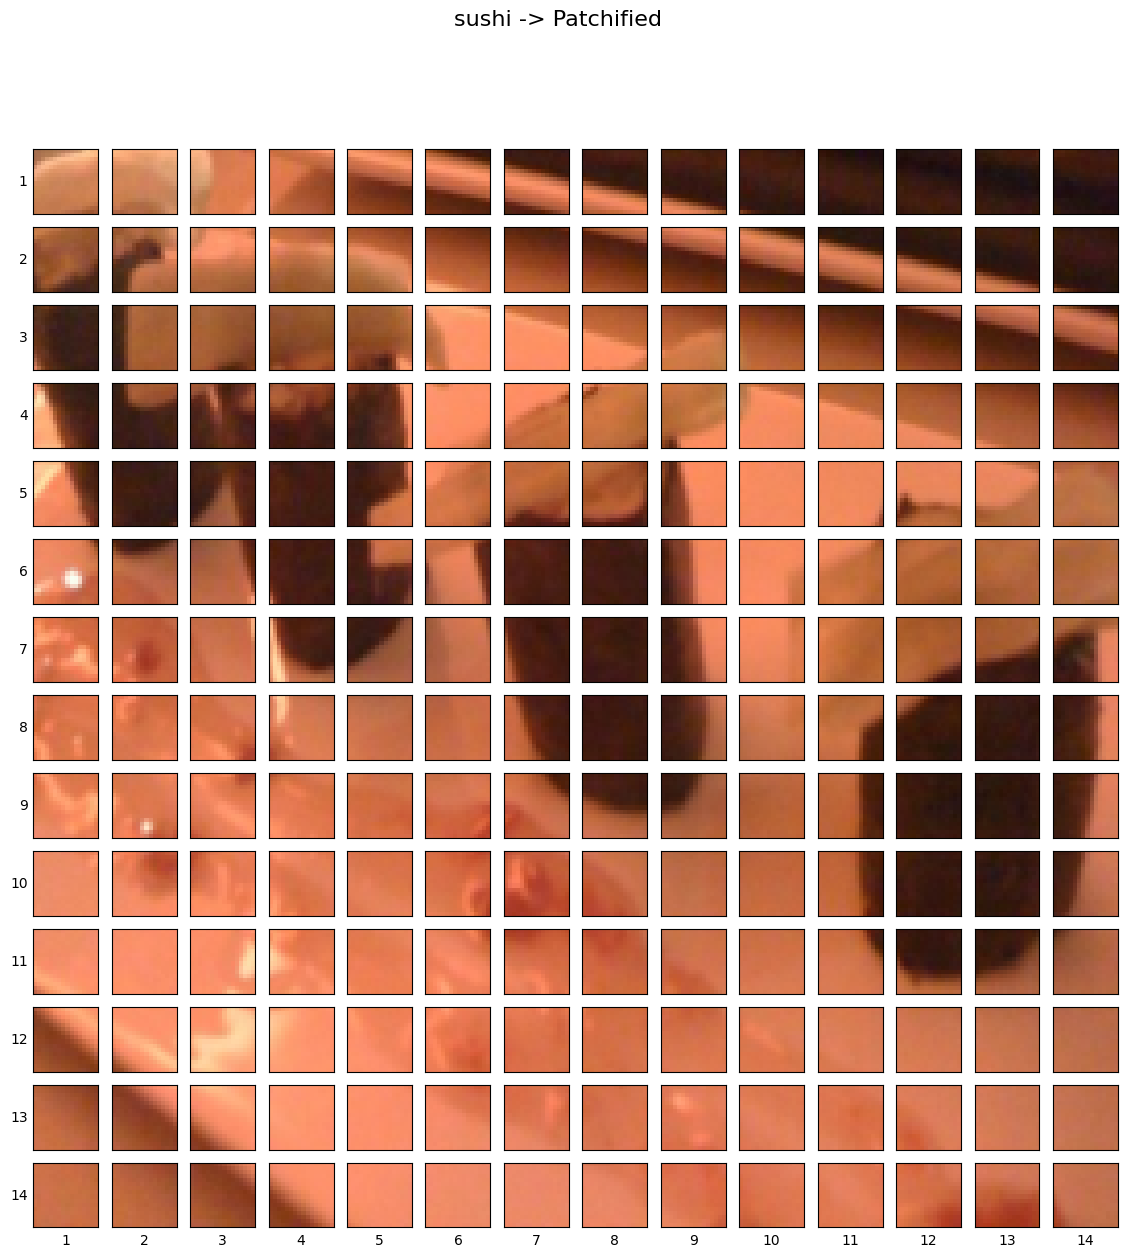

In [19]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

Here the image is patchified!
And that looks cooool ....!

Now how do we turn each of these patches into an embedding and convert them into a sequence?

Hint: we can use PyTorch layers. Can you guess which?

##Creating image patches with `torch.nn.Conv2d()`

By setting the kernel_size and stride parameters of a `torch.nn.Conv2d()` layer equal to the patch_size, we can effectively get a layer that splits our image into patches and creates a learnable embedding (referred to as a "Linear Projection" in the ViT paper) of each patch.

Remember our ideal input and output shapes for the patch embedding layer?

* **Input**: The image starts as 2D with size . H x W x C
* **Output** : The image gets converted to a 1D sequence of flattened 2D patches with size . N x (P **2 . C)

We create these with:
* torch.nn.Conv2d() for turning our image into patches of CNN feature maps.
* torch.nn.Flatten() for flattening the spatial dimensions of the feature map.



In [20]:
from torch import nn

# Set the patch size
patch_size = 16

# Create the Conv2d layer with hyperparameters from the ViT paper
conv2d = nn.Conv2d(in_channels=3,  #number of color channels,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)


Now we've got a convolutional layer, let's see what happens when we pass a single image through it.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

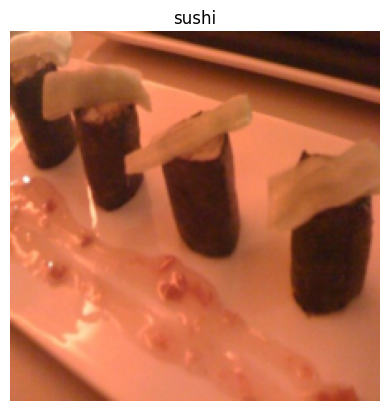

In [21]:
# view single image
plt.imshow(image.permute(1, 2, 0)) # Adjusting for matplot
plt.title(class_names[label])
plt.axis(False)


In [22]:
# Pass the image through convolutional layer
image_out_of_conv = conv2d(image.unsqueeze(0))  # add a single batch dimension (height, width, color_channels) -> (batch, height, width, color_channels)
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


Passing our image through the convolutional layer turns it into a series of 768 (this is the embedding size or

) feature/activation maps.

So its output shape can be read as:

torch.Size([1, 768, 14, 14]) -> [batch_size, embedding_dim, feature_map_height, feature_map_width]


Showing random convolutional feature maps from indexes: [64, 713, 77, 203, 229]


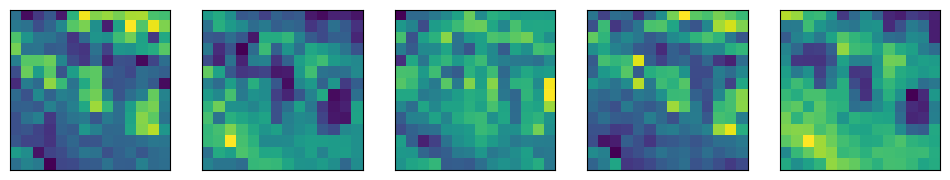

In [23]:
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 758), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);


Notice how the feature maps all kind of represent the original image, after visualizing a few more you can start to see the different major outlines and some major features.

he important thing to note is that these features may change over time as the neural network learns.

And because of these, these feature maps can be considered a learnable embedding of our image.

Let's check one out in numerical form.

In [24]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[0.4838, 0.5028, 0.6276, 0.4529, 0.4480, 0.5031, 0.4339, 0.2799,
           0.2440, 0.1512, 0.1242, 0.0874, 0.0759, 0.0972],
          [0.3921, 0.3111, 0.5685, 0.4672, 0.5246, 0.4791, 0.3508, 0.2284,
           0.2445, 0.4213, 0.3921, 0.2771, 0.2041, 0.1280],
          [0.2026, 0.2954, 0.3897, 0.3493, 0.2744, 0.6743, 0.6731, 0.6079,
           0.5045, 0.4295, 0.3170, 0.1814, 0.2118, 0.4062],
          [0.4081, 0.1545, 0.2844, 0.2471, 0.0441, 0.6491, 0.5195, 0.4981,
           0.4804, 0.6791, 0.6099, 0.5019, 0.4444, 0.3636],
          [0.8472, 0.1302, 0.3271, 0.1551, 0.2204, 0.5818, 0.4181, 0.4646,
           0.4323, 0.6400, 0.6246, 0.5205, 0.5854, 0.4907],
          [0.7599, 0.4488, 0.5138, 0.1989, 0.1424, 0.6224, 0.1773, 0.1359,
           0.3484, 0.6712, 0.5617, 0.4467, 0.4309, 0.4288],
          [0.6724, 0.4644, 0.5213, 0.3628, 0.2585, 0.4968, 0.2573, 0.1349,
           0.1878, 0.6427, 0.4957, 0.4461, 0.3110, 0.2269],
          [0.5700, 0.5948, 0.5617, 0.6275, 0.5223, 0.50

The `grad_fn` output of the `single_feature_map` and the `requires_grad=True` attribute means PyTorch is tracking the gradients of this feature map and it will be updated by gradient descent during training.

## Flattening the patch embedding with `torch.nn.Flatten()`



In [25]:
# The current tensor shape
print(f"Current tensor shape:{image_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width ]")

Current tensor shape:torch.Size([1, 768, 14, 14]) -> [batch, embedding_dim, feature_map_height, feature_map_width ]


As a special case, the patches can have spatial size , which means that the input sequence is obtained by simply flattening the spatial dimensions of the feature map and projecting to the Transformer dimension.

In [26]:
#  Create flatten layer
flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3) # flatten feature_map_width (dimension 3)


Putting all together
1. Taking a single image
2. Put in through the convolutional layer (conv2d) to turn image into 2d feature maps (patch embeddings).
3. Flatten the 2D Features map into a single sequence.


Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


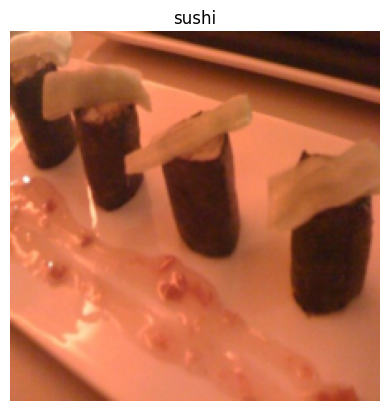

In [27]:
# 1 View single image
plt.imshow(image.permute(1, 2, 0))   # Adjust for matplotlib
plt.title(class_names[label])
plt.axis(False)
print(f"Original image shape: {image.shape}")

# 2 Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

#3 Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

Our `image_out_of_conv_flattened` shape is very close to our desired output shape

* Desired output shape: (flattened 2D patches) (196, 768) -> N x (P **2 .C)
* Current shape: (1, 768, 196)

The only difference is our current shape has a batch size and the dimensions are in a different order to the desired output.

How could we fix this?

We can do so with torch.Tensor.permute() just like we do when rearranging image tensors to plot them with matplotlib.

In [28]:
# Get flattened image patch embedding in right shape
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1)   # [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]
print(f"Patch embedding sequence shape: {image_out_of_conv_flattened_reshaped.shape} -> [batch_size, num_patches, embedding_size]")



Patch embedding sequence shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_size]


We've now matched the desired input and output shapes for the patch embedding layer of the ViT architecture using a couple of PyTorch layers.

How about we visualize one of the flattened feature maps?

(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

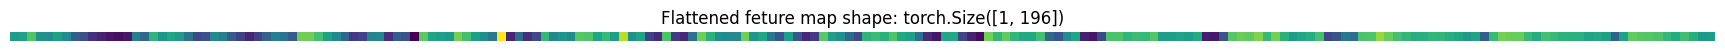

In [29]:
# Gets a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0]  # index: (batch_size, number_of_patches, embedding_dimension)

# Plot the flattened feature map visually
plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feture map shape: {single_flattened_feature_map.shape}")
plt.axis(False)

Hmm, the flattened feature map doesn't look like much visually, but that's not what we're concerned about, this is what will be the output of the patching embedding layer and the input to the rest of the ViT architecture.



How about we view the flattened feature map in tensor form?

In [30]:
# See the flattened feature map as a tensor
single_flattened_feature_map, single_flattened_feature_map.requires_grad,  single_flattened_feature_map.shape



(tensor([[0.4838, 0.5028, 0.6276, 0.4529, 0.4480, 0.5031, 0.4339, 0.2799, 0.2440,
          0.1512, 0.1242, 0.0874, 0.0759, 0.0972, 0.3921, 0.3111, 0.5685, 0.4672,
          0.5246, 0.4791, 0.3508, 0.2284, 0.2445, 0.4213, 0.3921, 0.2771, 0.2041,
          0.1280, 0.2026, 0.2954, 0.3897, 0.3493, 0.2744, 0.6743, 0.6731, 0.6079,
          0.5045, 0.4295, 0.3170, 0.1814, 0.2118, 0.4062, 0.4081, 0.1545, 0.2844,
          0.2471, 0.0441, 0.6491, 0.5195, 0.4981, 0.4804, 0.6791, 0.6099, 0.5019,
          0.4444, 0.3636, 0.8472, 0.1302, 0.3271, 0.1551, 0.2204, 0.5818, 0.4181,
          0.4646, 0.4323, 0.6400, 0.6246, 0.5205, 0.5854, 0.4907, 0.7599, 0.4488,
          0.5138, 0.1989, 0.1424, 0.6224, 0.1773, 0.1359, 0.3484, 0.6712, 0.5617,
          0.4467, 0.4309, 0.4288, 0.6724, 0.4644, 0.5213, 0.3628, 0.2585, 0.4968,
          0.2573, 0.1349, 0.1878, 0.6427, 0.4957, 0.4461, 0.3110, 0.2269, 0.5700,
          0.5948, 0.5617, 0.6275, 0.5223, 0.5036, 0.3381, 0.1437, 0.0935, 0.5174,
          0.5300

We've turned our single 2D image into a 1D learnable embedding vector (or "Linear Projection of Flattened Patches" in Figure 1 of the ViT paper).

##4.5 Turning the ViT patch embedding layer into a PyTorch module

Time to put everything we've done for creating the patch embedding into a single PyTorch layer

We can do so by subclassing nn.Module and creating a small PyTorch "model" to do all of the steps above.

Specifically we'll:
   > 1* Create a class called PatchEmbedding which subclasses nn.Module (so it can be used a PyTorch layer).

  > 2 * Initialize the class with the parameters `in_channels=3`, `patch_size=16` (for ViT-Base) and `embedding_dim=768` (this is
  for ViT-Base from Table 1).
  
  > 3 *Create a layer to turn an image into patches using nn.Conv2d() (just like in 4.3 above).
  Create a layer to flatten the patch feature maps into a single dimension (just like in 4.4 above).
  
  > 4 * Define a forward() method to take an input and pass it through the layers created in 3 and 4.
  
  
  >5 * Make sure the output shape reflects the required output shape of the ViT architecture ( N x P **2 . C
  ).

In [31]:
# 1 Create a class whcih subclasses nn.Module
class PatchEmbedding(nn.Module):
  """ Turns a 2D input image into a 1D sequence learnable embedding vector.
  Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
  """
  # 2 Initalize the new class with appropriate variables
  def __init__(self,
               in_channels:int=3,
               patch_size:int=16,
               embedding_dim:int=768):
    super().__init__()

    # 3 Create a layer to turn an Image into patches
    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size,
                             padding=0)

    # 4 Create a layer to flatten the path fearure maps into a single dimension
    self.flatten = nn.Flatten(start_dim=2,
                              end_dim=3)
    # 5 Define the forward method
  def forward(self, x):
    #  Create assertion to check that inputs are the correct shape
    image_resolution = x.shape[-1]
    assert image_resolution % patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {patch_size}"

    # Perform the foward pass
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)
    # Make sure the out: shape has the right order
    return x_flattened.permute(0, 2, 1)
    # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]





PatchEmbedding layer is created

Let's try it out on a single image.

In [32]:
set_seeds()

# Create an instance of patch embedding layer
patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

# Pass a single image through
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
print(f"Output patch embedding shape: {patch_embedded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768])


Here the  output shape matches the ideal input and output shapes we'd like to see from the patch embedding layer:


Here we make a summary of `PatchEmbedding` layer

In [33]:
# Create a random input shape
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250)   # will error because image size is incompatible with patch_size

# Get a summary of the input and outputs of PatchEmbedding (uncomment for full output)
summary(PatchEmbedding(),
        input_size=random_input_image, # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])



Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

## Creating the class token embedding.
Okay we've made the image patch embedding, time to get to work on the class token embedding


 We need to "preprend a learnable embedding to the sequence of embedded patches".

Let's start by viewing our sequence of embedded patches tensor (created in section 4.5) and its shape.


In [34]:
# View the patch embedded and patch embedding shape
print(patch_embedded_image)
print(f"patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[-0.7794,  0.1472, -0.0446,  ...,  0.4347, -0.4209,  0.2003],
         [-0.6814,  0.1030, -0.0515,  ...,  0.4051, -0.3824,  0.2538],
         [-0.7014,  0.0155, -0.0560,  ...,  0.4231, -0.4063,  0.2673],
         ...,
         [-0.5796,  0.0405, -0.0352,  ...,  0.2644, -0.3153,  0.2683],
         [-0.5843,  0.0120,  0.0537,  ...,  0.2609, -0.3567,  0.2097],
         [-0.6013,  0.0438, -0.0641,  ...,  0.3473, -0.3168,  0.2301]]],
       grad_fn=<PermuteBackward0>)
patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]


Let's create a learnable embedding for the class token.

To do so, we'll get the batch size and embedding dimension shape and then we'll create a `torch.ones()` tensor in the shape `[batch_size, 1, embedding_dimension]`.

And we'll make the tensor learnable by passing it to `nn.Parameter()` with `requires_grad=True`.

In [35]:
# Get the batch size and embedding dimensions
batch_size = patch_embedded_image.shape[0]
embedding_dim = patch_embedded_image.shape[-1]

# Create the class token embedding as a learnable parameter that shares the same size as the embedding dimension (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dim),
                           requires_grad=True)
# Show the first 10 examples of the class_token
print(class_token[:, :, :10])

# print the class_token shape

print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")



tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


here the number_of_tokens dimensions of class_token is  1 since we only want to prepend one class token value to the start of the patch embedding sequence.

Now we've got the class token embedding, let's prepend it to our sequence of image patches `patch_embedded_image`.



We can do so using `torch.cat()` and set `dim=1` (so class_token's number_of_tokens dimension is prepended to patch_embedded_image's number_of_patches dimension).

In [36]:


# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")


tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.7794,  0.1472, -0.0446,  ...,  0.4347, -0.4209,  0.2003],
         [-0.6814,  0.1030, -0.0515,  ...,  0.4051, -0.3824,  0.2538],
         ...,
         [-0.5796,  0.0405, -0.0352,  ...,  0.2644, -0.3153,  0.2683],
         [-0.5843,  0.0120,  0.0537,  ...,  0.2609, -0.3567,  0.2097],
         [-0.6013,  0.0438, -0.0641,  ...,  0.3473, -0.3168,  0.2301]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


Using torch.ones() to create the learnable class token is mostly for demonstration purposes only, in practice, you'd likely create it with torch.randn().


## Creating Position Embedding

Position embeddings are added to the patch embeddings to retain positional information. We use standard learnable 1D position embeddings, since we have not observed significant performance gains from using more advanced 2D-aware position embeddings (Appendix D.4). The resulting sequence of embedding vectors serves as input to the encoder.

By "retain positional information" the authors mean they want the architecture to know what "order" the patches come in. As in, patch two comes after patch one and patch three comes after patch two and on and on.

This positional information can be important when considering what's in an image (without positional information and a flattened sequence could be seen as having no order and thus no patch relates to any other patch).


To start creating the position embeddings, let's view our current embeddings.

In [37]:
# View the sequence of patch embeddings with the prepended class embedding

patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape



(tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-0.7794,  0.1472, -0.0446,  ...,  0.4347, -0.4209,  0.2003],
          [-0.6814,  0.1030, -0.0515,  ...,  0.4051, -0.3824,  0.2538],
          ...,
          [-0.5796,  0.0405, -0.0352,  ...,  0.2644, -0.3153,  0.2683],
          [-0.5843,  0.0120,  0.0537,  ...,  0.2609, -0.3567,  0.2097],
          [-0.6013,  0.0438, -0.0641,  ...,  0.3473, -0.3168,  0.2301]]],
        grad_fn=<CatBackward0>),
 torch.Size([1, 197, 768]))

In [38]:
# So let's make a learnable 1D embedding with torch.ones() to create .Epos

In [39]:


# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it  is learnable

# Show the first 10 sequences and 10  position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")


tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [40]:
# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it  is learnable

# Show the first 10 sequences and 10  position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")


tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


Position embedding is created !

Let's add them to our sequence of patch embedding with a prepend class token..


In [41]:
# Add the position embedding to the patch and class token embedding


In [42]:
# Add the position embedding to the patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")


tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.2206, 1.1472, 0.9554,  ..., 1.4347, 0.5791, 1.2003],
         [0.3186, 1.1030, 0.9485,  ..., 1.4051, 0.6176, 1.2538],
         ...,
         [0.4204, 1.0405, 0.9648,  ..., 1.2644, 0.6847, 1.2683],
         [0.4157, 1.0120, 1.0537,  ..., 1.2609, 0.6433, 1.2097],
         [0.3987, 1.0438, 0.9359,  ..., 1.3473, 0.6832, 1.2301]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positional embeddings added shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


Notice how the values of each of the elements in the embedding tensor increases by 1 (this is because of the position embeddings being created with torch.ones()).

##Putting it all together: from image to embedding

Let's now put everything together in a single code cell and go from input image (x) to output embedding (Zo).

We can do so by:

    > Setting the patch size (we'll use 16 as it's widely used throughout the paper and for ViT-Base).
    > Getting a single image, printing its shape and storing its height and width.
    > Adding a batch dimension to the single image so it's compatible with our PatchEmbedding layer.
    > Creating a PatchEmbedding layer (the one we made in section 4.5) with a patch_size=16 and embedding_dim=768 (from Table 1 for ViT-Base).
    > Passing the single image through the PatchEmbedding layer in 4 to create a sequence of patch embeddings.
    > Creating a class token embedding like in section 4.6.
    > Prepending the class token embedding to the patch embeddings created in step 5.
    > Creating a position embedding like in section 4.7.
    > Adding the position embedding to the class token and patch embeddings created in step 7.


We'll also make sure to set the random seeds with set_seeds() and print out the shapes of different tensors along the way.

In [43]:
set_seeds()

# 1 Set patch size
patch_size = 16

# 2 Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height , width = image.shape[1], image.shape[2]

# 3 Get  Image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimensions shape: {x.shape}")

# 4 Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)
# 5 Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# 6 Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True)
print(f"Class token embedding shape: {class_token.shape}")

# 7 Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token prepended shape: {patch_embedding_class_token.shape}")

# 8 Create position embedding
number_of_patches = int((height * width ) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True)    # make sure it's learnable

# 9 Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")


Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimensions shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token prepended shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


From a single image to patch and position embeddings in a single cell of code.

mapping equation 1 from the vision transformer paper to pytorch code


#5 Equation 2: Multi-Head Attention (MSA)
We've got our input data patchified and embedded, now let's move onto the next part of the ViT architecture.

To start, we'll break down the Transformer Encoder section into two parts (start small and increase when necessary).

The first being equation 2 and the second being equation 3.

Recall equation 2 states:

This indicates a Multi-Head Attention (MSA) layer wrapped in a LayerNorm (LN) layer with a residual connection (the input to the layer gets added to the output of the layer).


n saying this, to replicate these layers and residual connection with PyTorch code we can use:

    * Multi-Head Self Attention (MSA) - torch.nn.MultiheadAttention().
    * Norm (LN or LayerNorm) - torch.nn.LayerNorm().
    * Residual connection - add the input to output (we'll see this later on when we create the full Transformer Encoder block in section 7.1).


## The LayerNorm (LN) layer
Normalizes an input over the last dimension.

PyTorch's torch.nn.LayerNorm()'s main parameter is normalized_shape which we can set to be equal to the dimension size we'd like to normalize over (in our case it'll be

or 768 for ViT-Base).

What does it do?
Layer Normalization helps improve training time and model generalization (ability to adapt to unseen data).


##5.2 The Multi-Head Self Attention (MSA) layer

The power of the self-attention and multi-head attention (self-attention applied multiple times) were revealed in the form of the original Transformer architecture introduced in the Attention is all you need research paper.

Originally designed for text inputs, the original self-attention mechanism takes a sequence of words and then calculates which word should pay more "attention" to another word.

Since our input is a sequence of image patches rather than words, self-attention and in turn multi-head attention will calculate which patch of an image is most related to another patch, eventually forming a learned representation of an image.

But what's most important is that the layer does this on its own given the data (we don't tell it what patterns to learn).

And if the learned representation the layers form using MSA are good, we'll see the results in our model's performance.



##Replicating Equation 2 with PyTorch layers

Let's put everything we've discussed about the LayerNorm (LN) and Multi-Head Attention (MSA) layers in equation 2 into practice.

To do so, we'll:

> Create a class called MultiheadSelfAttentionBlock that inherits from torch.nn.Module.

> Initialize the class with hyperparameters from Table 1 of the ViT paper for the ViT-Base model.

>  reate a layer normalization (LN) layer with torch.nn.LayerNorm() with the normalized_shape parameter the same as our embedding dimension ( from Table 1).

>  Create a multi-head attention (MSA) layer with the appropriate embed_dim, num_heads, dropout and batch_first parameters.

>  Create a forward() method for our class passing the in the inputs through the LN layer and MSA layer.





In [44]:
# Create a class that inherits from nn.Module
class MultiheadSelfAttentionBlock(nn.Module):
  """ Creates a multi-head self-attention block ("MSA block" for short).
  """
  # 2 Initalize the class with hyperparameters from table1
  def __init__(self,
               embedding_dim:int=768,  # Hidden size D from Table 1 for ViT-Base
               num_heads: int=12, # Heads from table 1 for the ViT Base
               attn_dropout: float=0): # doesn't look like the paper uses any dropout in MSABlocks
    super().__init__()

    # 3 Create the Norm Layer (LN)
    self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

    # 4 Create the Multi-head Attention (MSA) layer
    self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     dropout=attn_dropout,
                                                     batch_first=True) # does our batch dime
    #5 Create a forward() method to pass the data through the layers
  def forward(self, x):
    x = self.layer_norm(x)
    attn_output, _ = self.multihead_attn(query=x,
                                          key=x,
                                           value=x,
                                          need_weights=False)
    return attn_output



MSA Block is created!

Let's try it out by create an instance of our MultiheadSelfAttentionBlock and passing through the patch_and_position_embedding variable we created in section 4.8.



In [45]:
# Create an instance of MSABlock
multihead_self_attention_block = MultiheadSelfAttentionBlock(embedding_dim=768, # from Table 1
                                                             num_heads=12) # from Table 1

# Pass patch and position image embedding through MSABlock
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")


Input shape of MSA block: torch.Size([1, 197, 768])
Output shape MSA block: torch.Size([1, 197, 768])


Note: The input and output shape of the data stays the same when it goes through the MSA Block

This doesn't mean the data doesn't change as it goes through.

You could try printing the input and output tensor to see how it changes (though this change will be across 1 * 197 * 768 values and could be hard to visualize).

##6 Equation 3: Multilayer Preceptron (MLP)
##6.1 The MLP layer(s)

The term MLP is quite broad as it can refer to almost any combination of multiple layers (hence the "multi" in multilayer perceptron).

But it generally follows the pattern of:

linear layer -> non-linear layer -> linear layer -> non-linear layer

In the the case of the ViT paper, the MLP structure is defined in section 3.1:



##6.3 Replicating Equation 3 with PyTorch layers

Let's put everything we've discussed about the LayerNorm (LN) and MLP (MSA) layers in equation 3 into practice.

To do so, we'll:
 > * Create a class called `MLPBlock` that inherits from `torch.nn.Module`.

 > * Initialize the class with hyperparameters from Table 1 and Table 3 of the ViT paper for the ViT-Base model.

> * Create a layer normalization (LN) layer with `torch.nn.LayerNorm()` with the normalized_shape parameter the same as our embedding dimension ( from Table 1).

> * Create a sequential series of MLP layers(s) using `torch.nn.Linear()`, `torch.nn.Dropout()` and `torch.nn.GELU()` with appropriate hyperparameter values from Table 1 and Table 3.

> *Create a `forward()` method for our class passing the in the inputs through the LN layer and MLP layer(s).

In [46]:
# 1. Create a class that inherits from nn.Module
class MLPBlock(nn.Module):
    """Creates a layer normalized multilayer perceptron block ("MLP block" for short)."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden Size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 dropout:float=0.1): # Dropout from Table 3 for ViT-Base
        super().__init__()

        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Create the Multilayer perceptron (MLP) layer(s)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(), # "The MLP contains two layers with a GELU non-linearity (section 3.1)."
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, # needs to take same in_features as out_features of layer above
                      out_features=embedding_dim), # take back to embedding_dim
            nn.Dropout(p=dropout) # "Dropout, when used, is applied after every dense layer.."
        )

    # 5. Create a forward() method to pass the data through the layers
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [47]:
# Create an instance of MLPBlock
mlp_block = MLPBlock(embedding_dim=768, # from Table 1
                     mlp_size=3072, # from Table 1
                     dropout=0.1) # from Table 3

# Pass output of MSABlock through MLPBlock
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")


Input shape of MLP block: torch.Size([1, 197, 768])
Output shape MLP block: torch.Size([1, 197, 768])


Equation 3 replicated (except for the residual connection on the end but we'll get to this in section 7.1)!

Now we've got equation's 2 and 3 in PyTorch code, let's now put them together to create the Transformer Encoder.


##Create the Transformer Encoder

Time to stack together our MultiheadSelfAttentionBlock (equation 2) and MLPBlock (equation 3) and create the Transformer Encoder of the ViT architecture.

In deep learning, an "encoder" or "auto encoder" generally refers to a stack of layers that "encodes" an input (turns it into some form of numerical representation).


We've created MSA and MLP blocks but what about the residual connections?

Residual connections (also called skip connections), were first introduced in the paper Deep Residual Learning for Image Recognition and are achieved by adding a layer(s) input to its subsequent output.

Where the subsequence output might be one or more layers later.

In the case of the ViT architecture, the residual connection means the input of the MSA block is added back to the output of the MSA block before it passes to the MLP block.

And the same thing happens with the MLP block before it goes onto the next Transformer Encoder block.

Or in pseudocode:
`x_input -> MSA_block -> [MSA_block_output + x_input] -> MLP_block -> [MLP_block_output + MSA_block_output + x_input] -> ...`




One of the main ideas behind residual connections is that they prevent weight values and gradient updates from getting too small and thus allow deeper networks and in turn allow deeper representations to be learned.

## 7.1 Creating a Transformer Encoder by combining our custom made layers

Let's see this in action and make a ViT Transformer Encoder with PyTorch by combining our previously created layers.

To do so, we'll:

> Create a class called `TransformerEncoderBlock` that inherits from `torch.nn.Module`
> Initialize the class with hyperparameters from Table 1 and Table 3 of the ViT paper for the ViT-Base model.

> Instantiate a MSA block for equation 2 using our MultiheadSelfAttentionBlock from section 5.2 with the appropriate parameters.

>  Instantiate a MLP block for equation 3 using our MLPBlock from section 6.2 with the appropriate parameters.

>  Create a `forward()` method for our TransformerEncoderBlock class.

>  Create a residual connection for the MSA block (for equation 2).

> Create a residual connection for the MLP block (for equation 3).



In [48]:
# Create a class that Inherits from nn.Module
class TransformerEncoderBlock(nn.Module):
  # 2 Initialize the class with hyperparameters from Table1 and Table 3
  def __init__(self,
               embedding_dim:int=768,
               num_heads:int=12,
               mlp_size:int=3072,
               mlp_dropout:float=0.1,
               attn_dropout:float=0):
    super().__init__()

    # 3 Create MSA block (equation 2)
    self.mas_block = MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                 num_heads=num_heads,
                                                 attn_dropout=attn_dropout)

    # 4 Create MLP Block (equation 3)
    self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                              mlp_size=mlp_size,
                              dropout=mlp_dropout)

    # 5 Create a forard() method
    def forward(self, x):

      # 6 Create residual connection for MSA block (add input to the outptut)
      x = self.msa_block(x) + x

      # 7 Create residual connection for MLP block (add the input to the output)
      x = self.mlp_block(x) + x

      return x




Transformer Encoder block created!

Let's get a torchinfo.summary() of passing an input of shape (1, 197, 768) -> (batch_size, num_patches, embedding_dimension) to our Transformer Encoder block.

In [49]:
# Create an instance of TransformerEncoderBlock
transformer_encoder_block = TransformerEncoderBlock()

# # Print an input and output summary of our Transformer Encoder (uncomment for full output)
# summary(model=transformer_encoder_block,
#         input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"])

You can see our input changing shape as it moves through all of the various layers in the MSA block and MLP block of the Transformer Encoder block before finally returning to its original shape at the very end

Note: Just because our input to the Transformer Encoder block has the same shape at the output of the block doesn't mean the values weren't manipulated, the whole goal of the Transformer Encoder block (and stacking them together) is to learn a deep representation of the input using the various layers in between.

##7.2 Creating a Transformer Encoder with PyTorch's Transformer layers

So far we've built the components of and the Transformer Encoder layer itself ourselves.

But because of their rise in popularity and effectiveness, PyTorch now has in-built Transformer layers as part of torch.nn.

For example, we can recreate the TransformerEncoderBlock we just created using torch.nn.TransformerEncoderLayer() and setting the same hyperparameters as above

In [50]:
# Create the same as above with torch.nn.TransformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True) # Normalize first or after MSA/MLP layers?

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [51]:
# # Get the output of PyTorch's version of the Transformer Encoder (uncomment for full output)
# summary(model=torch_transformer_encoder_layer,
#         input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"])



#8. Putting it all together to create ViT

Finally, to bring our own implementation of ViT to life, let's:

    * Create a class called ViT that inherits from torch.nn.Module.
    * Initialize the class with hyperparameters from Table 1 and Table 3 of the ViT paper for the ViT-Base model.
    * Make sure the image size is divisible by the patch size (the image should be split into even patches).
    * Calculate the number of patches using the formula N = Hw/P**2, where H is the image height, W is the image width and P is the patch size.
    * Create a learnable class embedding token (equation 1) as done above in section 4.6.
    * Create a learnable position embedding vector (equation 1) as done above in section 4.7.
    * Setup the embedding dropout layer as discussed in Appendix B.1 of the ViT paper.
    * Create the patch embedding layer using the PatchEmbedding class as above in section 4.5.
    * Create a series of Transformer Encoder blocks by passing a list of TransformerEncoderBlocks created in section 7.1 to torch.nn.Sequential() (equations 2 & 3).
    * Create the MLP head (also called classifier head or equation 4) by passing a torch.nn.LayerNorm() (LN) layer and a torch.nn.Linear(out_features=num_classes) layer (where num_classes is the target number of classes) linear layer to torch.nn.Sequential().
    * Create a forward() method that accepts an input.
    * Get the batch size of the input (the first dimension of the shape).
    * Create the patching embedding using the layer created in step 8 (equation 1).
    * Create the class token embedding using the layer created in step 5 and expand it across the number of batches found in step 11 using torch.Tensor.expand() (equation 1).
    * Concatenate the class token embedding created in step 13 to the first dimension of the patch embedding created in step 12 using torch.cat() (equation 1).
    * Add the position embedding created in step 6 to the patch and class token embedding created in step 14 (equation 1).
    * Pass the patch and position embedding through the dropout layer created in step 7.
    * Pass the patch and position embedding from step 16 through the stack of Transformer Encoder layers created in step 9 (equations 2 & 3).
    * Pass index 0 of the output of the stack of Transformer Encoder layers from step 17 through the classifier head created in step 10 (equation 4).
    * Dance and shout woohoo!!! We just built a Vision Transformer!

In [52]:
import torch
from torch import nn

class ViT(nn.Module):
    """Creates a Vision Transformer architecture (ViT-Base hyperparameters by default)."""

    def __init__(self,
                 img_size: int = 224,          # Training resolution (Table 3, ViT paper)
                 in_channels: int = 3,         # Number of input channels
                 patch_size: int = 16,         # Patch size
                 num_transformer_layers: int = 12,  # Layers (Table 1, ViT-Base)
                 embedding_dim: int = 768,     # Hidden size D
                 mlp_size: int = 3072,         # MLP hidden size
                 num_heads: int = 12,          # Multi-head attention heads
                 attn_dropout: float = 0.0,    # Attention dropout
                 mlp_dropout: float = 0.1,     # MLP dropout
                 embedding_dropout: float = 0.1,  # Dropout for embeddings
                 num_classes: int = 1000):     # Default ImageNet classes
        super().__init__()

        # Ensure image size divisible by patch size
        assert img_size % patch_size == 0, (
            f"Image size must be divisible by patch size. Got image_size={img_size}, patch_size={patch_size}."
        )

        # Calculate number of patches
        self.num_patches = (img_size * img_size) // (patch_size ** 2)

        # Learnable class token
        self.class_embedding = nn.Parameter(torch.randn(1, 1, embedding_dim))

        # Learnable positional embedding
        self.position_embedding = nn.Parameter(
            torch.randn(1, self.num_patches + 1, embedding_dim)
        )

        # Dropout for embeddings
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        # Patch embedding projection
        self.patch_embedding = PatchEmbedding(
            in_channels=in_channels,
            patch_size=patch_size,
            embedding_dim=embedding_dim
        )

        # Transformer encoder stack
        self.transformer_encoder = nn.Sequential(*[
            TransformerEncoderBlock(
                embedding_dim=embedding_dim,
                num_heads=num_heads,
                mlp_size=mlp_size,
                mlp_dropout=mlp_dropout
            )
            for _ in range(num_transformer_layers)
        ])

        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim, out_features=num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass of ViT"""
        batch_size = x.shape[0]

        # Class token (repeat for batch)
        class_token = self.class_embedding.expand(batch_size, -1, -1)

        # Patch embeddings
        x = self.patch_embedding(x)

        # Concatenate class token with patch embeddings
        x = torch.cat((class_token, x), dim=1)

        # Add positional embedding
        x = x + self.position_embedding

        # Embedding dropout
        x = self.embedding_dropout(x)

        # Pass through transformer encoder
        x = self.transformer_encoder(x)

        # Classification (use the [CLS] token, index 0)
        x = self.classifier(x[:, 0])

        return x


Let's create a quick demo to showcase what's happening with the class token embedding being expanded over the batch dimensions.

In [53]:
# Example of creating the class embedding and expanding over a batch dimension
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768))   # create a single learnable class token
class_token_embedding_batch = class_token_embedding_single.expand(batch_size, -1, -1) # expand over the batch
# expand the single learnable class token across the batch dimension, "-1" means to "infer the dimension"

# Print out the change in shapes
print(f"Shape of clas token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of clas token embedding batch: {class_token_embedding_batch.shape}")


Shape of clas token embedding single: torch.Size([1, 1, 768])
Shape of clas token embedding batch: torch.Size([32, 1, 768])


Notice how the first dimension gets expanded to the batch size and the other dimensions stay the same (because they're inferred by the "-1" dimensions in .expand(batch_size, -1, -1)).

Let's create a random tensor in the same shape as a single image, pass to an instance of ViT and see what happens.



In [54]:
set_seeds()

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224) #  (batch_size, color_channels, height, width)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = ViT(num_classes=len(class_names))

# pass the random image tensor to our ViT instance
vit(random_image_tensor)

NotImplementedError: Module [TransformerEncoderBlock] is missing the required "forward" function

##8.1 Getting a visual summary of our ViT model

We handcrafted our own version of the ViT architecture and seen that a random image tensor can flow all the way through it.

How about we use torchinfo.summary() to get a visual overview of the input and output shapes of all the layers in our model?


Note: The ViT paper states the use of a batch size of 4096 for training, however, this requires a far bit of CPU/GPU compute memory to handle (the larger the batch size the more memory required). So to make sure we don't get memory errors, we'll stick with a batch size of 32. You could always increase this later if you have access to hardware with more memory.

In [ ]:
from torchinfo import summary

# # Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
# summary(model=vit,
#         input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
#         # col_names=["input_size"], # uncomment for smaller output
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"]
# )

##Setting Up training code for our ViT Model
To train our model we can import the train() function from going_modular.going_modular.engine.

All we need is a loss function and an optimizer.

##Creating an Optimizer


##9.2 Creating a loss function

Strangely, searching the ViT paper for "loss" or "loss function" or "criterion" returns no results.

However, since the target problem we're working with is multi-class classification (the same for the ViT paper), we'll use torch.nn.CrossEntropyLoss().


##9.3 Training our ViT model
We'll start by importing the engine.py script from `going_modular.going_modular` then we'll setup the optimizer and loss function and finally we'll use the `train()` function from `engine.py` to train our ViT model for 10 epochs (we're using a smaller number of epochs than the ViT paper to make sure everything works).

In [ ]:
from going_modular.going_modular import engine

# Setup the optimizer to optimize the ViT model parameter using hyperparameters  from the ViT paper
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3,   # Base LR from Table 3 for ViT-* ImageNet-1k
                             betas=(0.9, 0.999),   # default values but also mentioned in ViT paper section 4.1 (Training & Fine-tuning)
                             weight_decay=0.3)  # from the ViT paper section 4.1 (Training & Fine-tuning) and Table 3 for ViT-* ImageNet-1k

# setup the loss function for multi-class classification
loss_fn = torch.nn.CrossEntropyLoss()

# set the seeds
set_seeds()

# Train the model and save the rraining results to a dict:
results = engine.train(model=vit,
                      train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epcohs=10,
                       device=device)


##9.4 What our training setup is missing

##9.5 Plot the loss curves of our ViT model
To check out our ViT model's loss curves, we can use the plot_loss_curves function from helper_functions.py we created in 04. PyTorch Custom Datasets section 7.8.



In [ ]:
from helper_functions import plot_loss_curves

# Plot the ViT model's loss curves
plot_loss_curves(results)

#10. Using a pretrained ViT from torchvision.models on the same dataset


##10.1 Why use a pretrained model?
An important note on many modern machine learning research papers is that much of the results are obtained with large datasets and vast compute resources.


And in modern day machine learning, the original fully trained ViT would likely not be considered a "super large" training setup (models are continually getting bigger and bigger).

##10.2 Getting a pretrained ViT model and creating a feature extractor

We can get a pretrained ViT model from `torchvision.models`.


In [ ]:
# The following requires torch v0.12+ and torchvision v0.13+
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

In [ ]:
# setting device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

# Finally, we'll get the pretrained ViT-Base with patch size 16 from torchvision.models and prepare it for our FoodVision Mini use case by turning it into a feature extractor transfer learning model.
# Specifically, we'll:


    * Get the pretrained weights for ViT-Base trained on ImageNet-1k from torchvision.models.ViT_B_16_Weights.DEFAULT (DEFAULT stands for best available).
    * Setup a ViT model instance via torchvision.models.vit_b_16, pass it the pretrained weights step 1 and send it to the target device.
    * Freeze all of the parameters in the base ViT model created in step 2 by setting their requires_grad attribute to False.
    * Update the classifier head of the ViT model created in step 2 to suit our own problem by changing the number of out_features to our number of classes (pizza, steak, sushi).


In [ ]:
# 1 Get pretrained weights for ViT Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
# requires torchvision >= 0.13, "DEFAULT" means best available

# 2 Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

#Freeze the base parameters
for parameter in pretrained_vit.parameters():
  parameter.requires_grad = False

# 4 change the classifier head (set the seeds to ensure same instantiation with linear head)
set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_feartres=len(class_names)).to(device)
# pretrained_vit # uncomment for model output

In [ ]:
# # Print a summary using torchinfo (uncomment for actual output)
# summary(model=pretrained_vit,
#         input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
#         # col_names=["input_size"], # uncomment for smaller output
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"]
# )

##10.3 Preparing data for the pretrained ViT mode

In [55]:
from helper_functions import download_data

# Download pizza , sushi , steak images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

And now we'll setup the training and test directory paths.

In [56]:
# Setup train and test directory paths
train_dir = image_path / "train"
test_dir = image_path  / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Finally, we'll transform our images into tensors and turn the tensors into DataLoaders.

Since we're using a pretrained model from `torchvision.models` we can call the `transforms()` method on it to get its required transforms.

Remember, if you're going to use a pretrained model, it's generally important to **ensure your own custom data is transformed/formatted in the same way the data the original model was trained on.**

In [57]:
# Get automatic tranforms from pretraied ViT weights
pretrained_vit_transforms =  pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


And now we've got transforms ready, we can turn our images into DataLoaders using the `data_setup.create_dataloaders()` method we created in 05. PyTorch Going Modular section 2.



In [59]:
# Setup the dataloaders
train_dataloader_pretrained , test_dataloader_pretrained , class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                           test_dir=test_dir,
                                                                                           transform=pretrained_vit_transforms,
                                                                                           batch_size=32)


##10.4 Train feature extractor ViT model
As before we'll use the Adam optimizer `(torch.optim.Adam())` with a learning rate of `1e-3` and `torch.nn.CrossEntropyLoss()` as the loss function.




In [62]:
from going_modular.going_modular import engine

# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT feature extractor model
set_seeds()
pretrained_vit_results = engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_pretrained,
                                      test_dataloader=test_dataloader_pretrained,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=10,
                                      device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

Holy cow!

Looks like our pretrained ViT feature extractor performed far better than our custom ViT model trained from scratch (in the same amount of time).

Let's get visual.


##10.5 Plot feature extractor ViT model loss curves
our pretrained model numbers look good on the training and test sets.

Let's see the curves.


In [63]:
# Plot the loss curves
from helper_functions import plot_loss_curves

plot_loss_curves(pretrained_vit_results)


NameError: name 'pretrained_vit_results' is not defined

## 10.6 Save feature extractor ViT model and check file size

It looks like our ViT feature extractor model is performing quite well for our Food Vision Mini problem.

Perhaps we might want to try deploying it and see how it goes in production (in this case, deploying means putting our trained model in an application someone could use, say taking photos on their smartphone of food and seeing if our model thinks it's pizza, steak or sushi).

To do so we can first save our model with the `utils.save_model()` function we created in 05. PyTorch Going Modular section 5.

In [64]:
# Save the model
from going_modular.going_modular import utils

utils.save_model(model=pretrained_vit,
                 target_dir="models",
                 model_name="08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth")

[INFO] Saving model to: models/08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth


##11 Making predictions on a custom image
And finally, we'll finish with the ultimate test, predicting on our own custom data.


To do so, let's use the pred_and_plot() function we created in 06. PyTorch Transfer Learning section 6.

IndexError: list index out of range

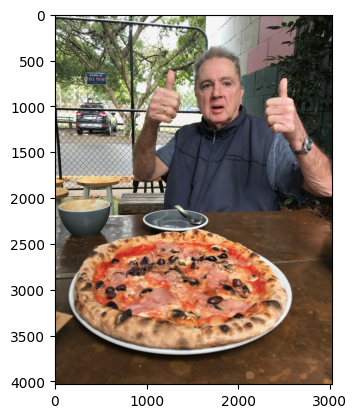

In [66]:
import requests

# Import function to make predictions on images and plot them
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = image_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)
